In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from tqdm.auto import tqdm

d:\Personal\second year\DS\clone\new\Spa-Former\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Architecture
Spa-Former for image inpainting.
- Generator: encoder-decoder with skip fusion.
- Gated Transformer blocks which use channel attention are used in the Generator
- Discriminator: PatchGAN-style conv network.


In [2]:
# supporting class for layer normalization
class ChannelLayerNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.ln = nn.LayerNorm(dim)

    def forward(self, x):
        x = x.permute(0, 2, 3, 1)
        x = self.ln(x)
        x = x.permute(0, 3, 1, 2)
        return x

### Spa-Attention Module
Sparse channel attention block used inside transformer layers.
- Builds attention with $q^\top k$ per head.
- Uses ReLU to keep sparse positive responses.
- Applies a spatial gate before projection.


In [3]:
class SpaAttention(nn.Module):
    def __init__(self, dim, num_heads=4, bias=False):
        super().__init__()
        assert dim % num_heads == 0, f"dim ({dim}) must be divisible by num_heads ({num_heads})"

        self.num_heads = num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))

        self.norm1 = ChannelLayerNorm(dim)
        self.gate = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=1, bias=True),
            nn.GELU()
        )

        self.qkv = nn.Conv2d(dim, dim * 3, kernel_size=1, bias=bias)
        self.qkv_dwconv = nn.Conv2d(dim * 3, dim * 3, kernel_size=3, stride=1, padding=1, groups=dim * 3, bias=bias)
        self.project_out = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)

    def forward(self, x):
        b, c, h, w = x.shape
        x_n = self.norm1(x)
        g = self.gate(x_n)

        qkv = self.qkv_dwconv(self.qkv(x_n))
        q, k, v = qkv.chunk(3, dim=1)

        c_per_head = c // self.num_heads
        n = h * w

        # (B, head, N, C_head)
        q = q.view(b, self.num_heads, c_per_head, n).permute(0, 1, 3, 2) # query
        k = k.view(b, self.num_heads, c_per_head, n).permute(0, 1, 3, 2) # key
        v = v.view(b, self.num_heads, c_per_head, n).permute(0, 1, 3, 2) # value

        q = F.normalize(q, dim=2)
        k = F.normalize(k, dim=2)

        # (B, heads, C_head, C_head): Instead of NxN, we have CxC UNLIKE ViT
        attn = (q.transpose(-2, -1) @ k) * self.temperature 
        attn = F.relu(attn)

        out = v @ attn
        out = out.permute(0, 1, 3, 2).contiguous().view(b, c, h, w)

        out = out * g
        out = self.project_out(out)
        return out


class FeedForward(nn.Module):
    def __init__(self, dim, expansion_factor=2.66):
        super().__init__()
        hidden = int(dim * expansion_factor)

        self.norm = ChannelLayerNorm(dim)
        self.conv = nn.Sequential(
            nn.Conv2d(dim, hidden * 2, kernel_size=1, bias=False),
            nn.Conv2d(hidden * 2, hidden * 2, kernel_size=3, stride=1, padding=1, groups=hidden * 2, bias=False),
        )
        self.linear = nn.Conv2d(hidden, dim, kernel_size=1, bias=False)

    def forward(self, x):
        x_n = self.norm(x)
        x1, x2 = self.conv(x_n).chunk(2, dim=1)
        out = F.gelu(x1) * x2
        out = self.linear(out)
        return out



### Gated Transformer Block
Combines attention and FFN with residual connections.
- $x \leftarrow x + \mathrm{Attention}(x)$
- $x \leftarrow x + \mathrm{FFN}(x)$
- Keeps block stable and easy to stack.


In [4]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, in_ch, head, expansion_factor=2.66):
        super().__init__()
        self.attn = SpaAttention(dim=in_ch, num_heads=head, bias=False)
        self.ffn = FeedForward(dim=in_ch, expansion_factor=expansion_factor)

    def forward(self, x):
        x = x + self.attn(x)
        x = x + self.ffn(x)
        return x


class Downsample(nn.Module):
    def __init__(self, num_ch):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_ch, num_ch * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(num_ch * 2, track_running_stats=False),
            nn.GELU(),
        )

    def forward(self, x):
        return self.body(x)



### Encoder
Hierarchical feature extractor with 4 stages.
- Input is `[image, mask]` as 4 channels.
- Downsampling doubles channels and halves resolution.
- Returns pyramid features for decoder skip links.


In [5]:
class Encoder(nn.Module):
    def __init__(self, ngf=48, num_blocks=(1, 2, 3, 4), num_heads=(1, 2, 4, 8), expansion_factor=2.66):
        super().__init__()

        self.start = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(4, ngf, kernel_size=7, padding=0),
            nn.InstanceNorm2d(ngf),
            nn.GELU(),
        )

        self.trane256 = nn.Sequential(*[
            TransformerEncoderBlock(in_ch=ngf, head=num_heads[0], expansion_factor=expansion_factor)
            for _ in range(num_blocks[0])
        ])

        self.down128 = Downsample(ngf)
        self.trane128 = nn.Sequential(*[
            TransformerEncoderBlock(in_ch=ngf * 2, head=num_heads[1], expansion_factor=expansion_factor)
            for _ in range(num_blocks[1])
        ])

        self.down64 = Downsample(ngf * 2)
        self.trane64 = nn.Sequential(*[
            TransformerEncoderBlock(in_ch=ngf * 4, head=num_heads[2], expansion_factor=expansion_factor)
            for _ in range(num_blocks[2])
        ])

        self.down32 = Downsample(ngf * 4)
        self.trane32 = nn.Sequential(*[
            TransformerEncoderBlock(in_ch=ngf * 8, head=num_heads[3], expansion_factor=expansion_factor)
            for _ in range(num_blocks[3])
        ])

    def forward(self, x, mask=None, return_pyramid=False):
        if mask is None:
            mask = torch.ones(x.size(0), 1, x.size(2), x.size(3), dtype=x.dtype, device=x.device)

        feat = torch.cat([x, mask], dim=1)

        f256 = self.trane256(self.start(feat))
        f128 = self.trane128(self.down128(f256))
        f64 = self.trane64(self.down64(f128))
        f32 = self.trane32(self.down32(f64))

        if return_pyramid:
            return f256, f128, f64, f32
        return f32



### Upsampling and Decoder
Reconstructs image features back to full resolution.
- Nearest-neighbor upsample + conv refinement.
- Fuses skip features from encoder at each stage.
- Final $\tanh$ produces RGB output in $[-1, 1]$.


In [6]:
class Upsample(nn.Module):
    def __init__(self, num_ch):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_ch, num_ch // 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(num_ch // 2, track_running_stats=False),
            nn.GELU(),
        )

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.body(x)


class Decoder(nn.Module):
    def __init__(self, ngf=48, num_blocks=(1, 2, 3, 4), num_heads=(1, 2, 4, 8), expansion_factor=2.66):
        super().__init__()

        self.up64 = Upsample(ngf * 8)
        self.fuse64 = nn.Conv2d(ngf * 8, ngf * 4, kernel_size=1, stride=1, bias=False)
        self.trand64 = nn.Sequential(*[
            TransformerEncoderBlock(in_ch=ngf * 4, head=num_heads[2], expansion_factor=expansion_factor)
            for _ in range(num_blocks[2])
        ])

        self.up128 = Upsample(ngf * 4)
        self.fuse128 = nn.Conv2d(ngf * 4, ngf * 2, kernel_size=1, stride=1, bias=False)
        self.trand128 = nn.Sequential(*[
            TransformerEncoderBlock(in_ch=ngf * 2, head=num_heads[1], expansion_factor=expansion_factor)
            for _ in range(num_blocks[1])
        ])

        self.up256 = Upsample(ngf * 2)
        self.fuse256 = nn.Conv2d(ngf * 2, ngf, kernel_size=1, stride=1, bias=False)
        self.trand256 = nn.Sequential(*[
            TransformerEncoderBlock(in_ch=ngf, head=num_heads[0], expansion_factor=expansion_factor)
            for _ in range(num_blocks[0])
        ])

        self.out = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(ngf, 3, kernel_size=7, padding=0),
        )

    def forward(self, f256, f128, f64, f32):
        out64 = self.up64(f32)
        out64 = self.fuse64(torch.cat([f64, out64], dim=1))
        out64 = self.trand64(out64)

        out128 = self.up128(out64)
        out128 = self.fuse128(torch.cat([f128, out128], dim=1))
        out128 = self.trand128(out128)

        out256 = self.up256(out128)
        out256 = self.fuse256(torch.cat([f256, out256], dim=1))
        out256 = self.trand256(out256)

        out = torch.tanh(self.out(out256))
        return out


class Generator(nn.Module):
    def __init__(self, ngf=48, num_blocks=(1, 2, 3, 4), num_heads=(1, 2, 4, 8), expansion_factor=2.66, use_input_noise=True):
        super().__init__()
        self.use_input_noise = use_input_noise
        self.encoder = Encoder(ngf=ngf, num_blocks=num_blocks, num_heads=num_heads, expansion_factor=expansion_factor)
        self.decoder = Decoder(ngf=ngf, num_blocks=num_blocks, num_heads=num_heads, expansion_factor=expansion_factor)

    def forward(self, x, mask):
        if self.use_input_noise:
            x = x + torch.randn_like(x) * (1.0 / 128.0)
        f256, f128, f64, f32 = self.encoder(x, mask, return_pyramid=True)
        out = self.decoder(f256, f128, f64, f32)
        return out


def composite_with_known_regions(pred, corrupted, mask, known_is_one=True):
    if known_is_one:
        return pred * (1.0 - mask) + corrupted * mask
    return pred * mask + corrupted * (1.0 - mask)



#### Spectral Norm Helper
Utility wrapper for optional spectral normalization.
- Applied to discriminator conv layers.
- Constrains the layer Lipschitz constant $K$, so $\|\nabla f(x)\| \le K$.
- Helps stabilize GAN training.
- Can be toggled on/off by flag.


In [7]:
def spectral_norm(module, mode=True):
    if mode:
        return nn.utils.spectral_norm(module)

    return module

### GAN Discriminator
Patch-based discriminator used during training.
- Outputs a patch map (not one scalar), with each patch having a realism score.
- Returns intermediate conv features too.
- Supports adversarial and feature-based losses.


In [8]:
class Discriminator(nn.Module):
    def __init__(self, in_channels, use_sigmoid=True, use_spectral_norm=True, init_weights=True):
        super(Discriminator, self).__init__()
        self.use_sigmoid = use_sigmoid

        self.conv1 = self.features = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=in_channels, out_channels=64, kernel_size=4, stride=2, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv2 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv3 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv4 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=256, out_channels=512, kernel_size=4, stride=1, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv5 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=512, out_channels=1, kernel_size=4, stride=1, padding=1, bias=not use_spectral_norm), use_spectral_norm),
        )

    def forward(self, x):
        conv1 = self.conv1(x)
        conv2 = self.conv2(conv1)
        conv3 = self.conv3(conv2)
        conv4 = self.conv4(conv3)
        conv5 = self.conv5(conv4)

        outputs = conv5
        if self.use_sigmoid:
            outputs = torch.sigmoid(conv5)

        return outputs, [conv1, conv2, conv3, conv4, conv5]

## Training
Functions for one-step update and full epoch loop.
- `train_step`: updates D then G.
- `train_model`: loops through dataloader and logs averages.
- Supports optional perceptual/style losses.

Loss equations used in the training setup:

$$
\mathcal{L}_r = \lVert I_{out} - I_{gt} \rVert_1
$$

$$
\mathcal{L}_a = \mathbb{E}_{I_{gt}}\left[\log D(I_{gt})\right] + \mathbb{E}_{I_{out}}\left[\log\left(1 - D(I_{out})\right)\right]
$$

$$
\mathcal{L}_p = \sum_i \left\lVert \phi_i(I_{out}) - \phi_i(I_{gt}) \right\rVert_1
$$

$$
\mathcal{L}_s = \sum_i \left\lVert \phi_i(I_{out})\,\phi_i^{\top}(I_{out}) - \phi_i(I_{gt})\,\phi_i^{\top}(I_{gt}) \right\rVert_1
$$



In [9]:
# Train helpers (simple GAN + optional perceptual/style)
bce = nn.BCELoss()


def d_loss_fn(d_real, d_fake):
    real_loss = bce(d_real, torch.ones_like(d_real))
    fake_loss = bce(d_fake, torch.zeros_like(d_fake))
    return 0.5 * (real_loss + fake_loss)


def g_adv_loss_fn(d_fake):
    return bce(d_fake, torch.ones_like(d_fake))


def l1_loss_fn(fake_img, real_img):
    return F.l1_loss(fake_img, real_img)


def gram_matrix(x):
    b, c, h, w = x.shape
    f = x.view(b, c, h * w)
    g = torch.bmm(f, f.transpose(1, 2))
    return g / (c * h * w)


class SimpleVGGFeatureExtractor(nn.Module):
    def __init__(self, layers=(3, 8, 15, 22)):
        super().__init__()
        self.layers = set(layers)
        self.max_layer = max(layers)

        try:
            vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
            self.pretrained_ok = True
        except Exception:
            vgg = models.vgg16(weights=None).features
            self.pretrained_ok = False

        self.features = vgg.eval()
        for p in self.features.parameters():
            p.requires_grad = False

        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x + 1.0) * 0.5
        x = (x - self.mean) / self.std

        outs = []
        h = x
        for i, layer in enumerate(self.features):
            h = layer(h)
            if i in self.layers:
                outs.append(h)
            if i >= self.max_layer:
                break
        return outs


def perceptual_style_loss(fake_img, real_img, feat_net):
    if feat_net is None:
        z = torch.tensor(0.0, device=fake_img.device)
        return z, z

    fake_feats = feat_net(fake_img)
    real_feats = feat_net(real_img)

    p_loss = 0.0
    s_loss = 0.0
    for ff, rf in zip(fake_feats, real_feats):
        p_loss = p_loss + F.l1_loss(ff, rf)
        s_loss = s_loss + F.l1_loss(gram_matrix(ff), gram_matrix(rf))
    return p_loss, s_loss


def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag


def unpack_batch(batch, device):
    # Supports tuple/list: (img_truth, mask) or dict with keys 'img' and 'mask'.
    if isinstance(batch, dict):
        img_truth = batch['img'].to(device)
        mask = batch['mask'].to(device)
    else:
        img_truth, mask = batch
        img_truth = img_truth.to(device)
        mask = mask.to(device)

    # normalize image to [-1, 1] if needed
    if img_truth.max() > 1.0 or img_truth.min() < -1.0:
        img_truth = img_truth.clamp(0, 1) * 2.0 - 1.0
    return img_truth, mask


def train_step(G, D, batch, opt_G, opt_D, device,
               feat_net=None,
               lambda_adv=0.1, lambda_l1=1.0, lambda_per=0.1, lambda_sty=250.0):
    G.train()
    D.train()

    img_truth, mask = unpack_batch(batch, device)
    img_m = img_truth * mask

    # 1) D update
    set_requires_grad(D, True)
    opt_D.zero_grad()

    with torch.no_grad():
        pred_fake = G(img_m, mask)
        img_fake = composite_with_known_regions(pred_fake, img_m, mask, known_is_one=True)

    d_real, _ = D(img_truth)
    d_fake, _ = D(img_fake.detach())
    loss_d = d_loss_fn(d_real, d_fake)
    loss_d.backward()
    opt_D.step()

    # 2) G update
    set_requires_grad(D, False)
    opt_G.zero_grad()

    pred_fake = G(img_m, mask)
    img_fake = composite_with_known_regions(pred_fake, img_m, mask, known_is_one=True)
    d_fake_for_g, _ = D(img_fake)

    loss_g_adv = g_adv_loss_fn(d_fake_for_g)
    loss_g_l1 = l1_loss_fn(img_fake, img_truth)
    loss_g_per, loss_g_sty = perceptual_style_loss(img_fake, img_truth, feat_net)

    loss_g = (
        lambda_adv * loss_g_adv
        + lambda_l1 * loss_g_l1
        + lambda_per * loss_g_per
        + lambda_sty * loss_g_sty
    )

    loss_g.backward()
    opt_G.step()

    return {
        'loss_d': float(loss_d.detach()),
        'loss_g': float(loss_g.detach()),
        'loss_g_adv': float(loss_g_adv.detach()),
        'loss_g_l1': float(loss_g_l1.detach()),
        'loss_g_per': float(loss_g_per.detach()),
        'loss_g_sty': float(loss_g_sty.detach()),
    }


def train_model(
    G,
    D,
    dataloader,
    epochs=1,
    lr=1e-4,
    device='cpu',
    use_perceptual_style=True,
    ckpt_path='checkpoints/spaformer_latest.pt',
    load_ckpt=False,
    save_ckpt=True,
    save_every=5,
):
    from pathlib import Path

    G.to(device)
    D.to(device)

    feat_net = None
    if use_perceptual_style:
        feat_net = SimpleVGGFeatureExtractor().to(device)
        feat_net.eval()

    opt_G = torch.optim.AdamW(G.parameters(), lr=lr, betas=(0.5, 0.9))
    opt_D = torch.optim.AdamW(D.parameters(), lr=lr, betas=(0.5, 0.9))

    history = []
    start_epoch = 0

    ckpt_file = Path(ckpt_path) if ckpt_path is not None else None
    if load_ckpt and ckpt_file is not None and ckpt_file.exists():
        ckpt = torch.load(str(ckpt_file), map_location=device, weights_only=False)
        G.load_state_dict(ckpt['G'])
        D.load_state_dict(ckpt['D'])
        if 'opt_G' in ckpt:
            opt_G.load_state_dict(ckpt['opt_G'])
        if 'opt_D' in ckpt:
            opt_D.load_state_dict(ckpt['opt_D'])
        history = ckpt.get('history', [])
        start_epoch = int(ckpt.get('epoch', -1)) + 1
        print(f"Loaded checkpoint: {ckpt_file} (resume at epoch {start_epoch + 1})")

    for epoch in range(start_epoch, start_epoch + epochs):
        running = {'loss_d': 0.0, 'loss_g': 0.0, 'loss_g_adv': 0.0, 'loss_g_l1': 0.0, 'loss_g_per': 0.0, 'loss_g_sty': 0.0}
        count = 0

        progress = tqdm(dataloader, desc=f"Epoch {epoch+1}/{start_epoch + epochs}", leave=False)
        for step, batch in enumerate(progress, start=1):
            metrics = train_step(G, D, batch, opt_G, opt_D, device, feat_net=feat_net)
            for k in running:
                running[k] += metrics[k]
            count += 1
            progress.set_postfix({'D': f"{metrics['loss_d']:.4f}", 'G': f"{metrics['loss_g']:.4f}"})

        for k in running:
            running[k] /= max(count, 1)

        history.append(running)
        print(f"Epoch {epoch+1} | D: {running['loss_d']:.4f} | G: {running['loss_g']:.4f} | L1: {running['loss_g_l1']:.4f}")

        if save_ckpt and ckpt_file is not None and ((epoch + 1) % save_every == 0):
            ckpt_file.parent.mkdir(parents=True, exist_ok=True)
            torch.save({
                'epoch': epoch,
                'G': G.state_dict(),
                'D': D.state_dict(),
                'opt_G': opt_G.state_dict(),
                'opt_D': opt_D.state_dict(),
                'history': history,
            }, str(ckpt_file))
            print(f"Saved checkpoint: {ckpt_file}")

    return history


# Example usage (with your own DataLoader):
# G = Generator(use_input_noise=True)
# D = Discriminator(in_channels=3, use_sigmoid=True, use_spectral_norm=True)
# history = train_model(G, D, train_loader, epochs=10, lr=1e-4, device='cuda', use_perceptual_style=True)





train_loader ready
img shape: (4, 3, 256, 256) dtype: torch.float32 min/max: 0.0 1.0
mask shape: (4, 1, 256, 256) dtype: torch.float32 min/max: 0.0 1.0
sample path: celeba_hq_256\13813.jpg


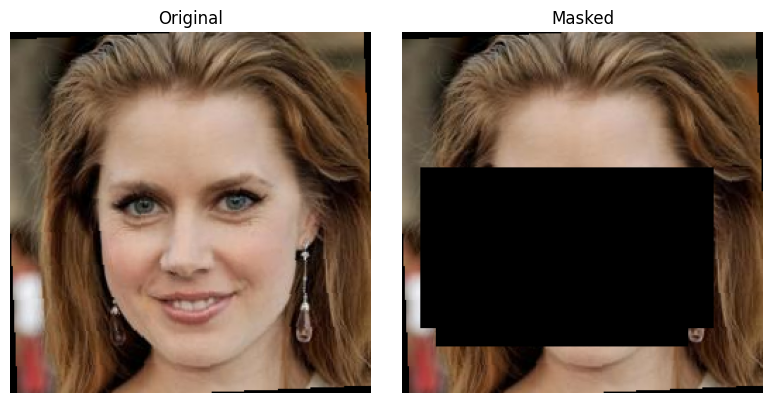

In [10]:
# Train loader sample using dataloader.py
from types import SimpleNamespace
import matplotlib.pyplot as plt
from dataloader.dataloader import dataloader as make_dataloader

opt = SimpleNamespace(
    img_file='celeba_hq_256',
    mask_type=[0, 1, 2, 4],
    isTrain=True,
    batchSize=4,
    no_shuffle=False,
    nThreads=0,
    loadSize=[256, 256],
    fineSize=[256, 256],
    resize_or_crop='resize_and_crop',
    no_augment=False,
    no_flip=False,
    no_rotation=False,
)

train_loader = make_dataloader(opt)
batch = next(iter(train_loader))

img = batch['img']
mask = batch['mask']
img_path = batch['img_path']

print('train_loader ready')
print('img shape:', tuple(img.shape), 'dtype:', img.dtype, 'min/max:', float(img.min()), float(img.max()))
print('mask shape:', tuple(mask.shape), 'dtype:', mask.dtype, 'min/max:', float(mask.min()), float(mask.max()))
print('sample path:', img_path[0])

# plot original + masked sample
sample_img = img[0].detach().cpu()                 # [3, H, W]
sample_mask = mask[0].detach().cpu()               # [1, H, W] or [H, W]
if sample_mask.dim() == 3:
    sample_mask_2d = sample_mask[0]
else:
    sample_mask_2d = sample_mask

masked_img = sample_img * sample_mask_2d.unsqueeze(0)

orig_np = sample_img.permute(1, 2, 0).clamp(0, 1)
masked_np = masked_img.permute(1, 2, 0).clamp(0, 1)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(orig_np)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(masked_np)
plt.title('Masked')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Quick sanity training on 50 images
from types import SimpleNamespace
from torch.utils.data import Subset, DataLoader
from dataloader.dataloader import dataloader as make_dataloader

opt = SimpleNamespace(
    img_file='celeba_hq_256',
    mask_type=[0, 1, 2, 4],
    isTrain=True,
    batchSize=4,
    no_shuffle=False,
    nThreads=0,
    loadSize=[256, 256],
    fineSize=[256, 256],
    resize_or_crop='resize_and_crop',
    no_augment=False,
    no_flip=False,
    no_rotation=False,
)

full_loader = make_dataloader(opt)
dataset = full_loader.dataset
n = 2000
subset_idx = torch.randperm(len(dataset))[:n].tolist()
subset_ds = Subset(dataset, subset_idx)
train_loader = DataLoader(
    subset_ds,
    batch_size=opt.batchSize,
    shuffle=True,
    num_workers=int(opt.nThreads),
)

print(f'Using subset of {n} images for sanity check')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
G = Generator(use_input_noise=True)
D = Discriminator(in_channels=3, use_sigmoid=True, use_spectral_norm=True)

history = train_model(
    G, D, train_loader,
    epochs=10,
    lr=1e-4,
    device=device,
    use_perceptual_style=False,
    ckpt_path='checkpoints/spaformer_latest.pt',
    load_ckpt=False,
    save_ckpt=True,
    save_every=5,
)
history[-1]



Using subset of 2000 images for sanity check


Epoch 1/10:   0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
torch.cuda.isa_available()

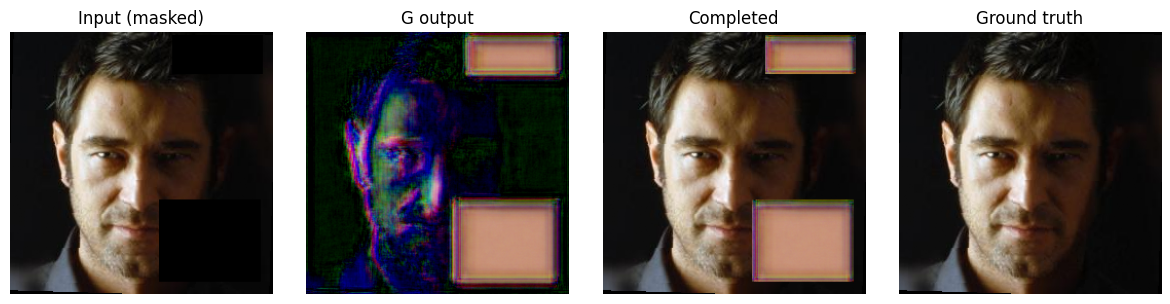

: 

: 

: 

: 

: 

In [ ]:
# Sample Generator I/O visualization (input -> G output -> completed image)
G.eval()

batch = next(iter(train_loader))
img_truth = batch['img'].to(device)   # [B,3,H,W], usually in [0,1]
mask = batch['mask'].to(device)       # [B,1,H,W], 1=known, 0=hole (as used in your code)

img_m = img_truth * mask  # input to Generator (masked image)

with torch.no_grad():
    pred = G(img_m, mask)  # raw Generator output
    completed = composite_with_known_regions(pred, img_m, mask, known_is_one=True)

# first sample
x_in = img_m[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
x_out = pred[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
x_comp = completed[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
x_gt = img_truth[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)

plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1); plt.imshow(x_in);   plt.title("Input (masked)"); plt.axis("off")
plt.subplot(1, 4, 2); plt.imshow(x_out);  plt.title("G output");        plt.axis("off")
plt.subplot(1, 4, 3); plt.imshow(x_comp); plt.title("Completed");       plt.axis("off")
plt.subplot(1, 4, 4); plt.imshow(x_gt);   plt.title("Ground truth");    plt.axis("off")
plt.tight_layout()
plt.show()
